In [65]:
!pip install timm albumentations opencv-python tqdm matplotlib

In [22]:
import os
import cv2
import random
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import timm
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [4]:
class HiDFLocalizationDataset(Dataset):
    def __init__(self, real_dir, fake_dir, transform=None):
        self.real_dir = real_dir
        self.fake_dir = fake_dir
        self.transform = transform
        
        print("Scanning directories and mapping valid pairs...")
        
        real_files = os.listdir(real_dir)
        self.real_map = {os.path.splitext(f)[0]: f for f in real_files}
        
        all_fakes = os.listdir(fake_dir)
        self.valid_pairs = []
        
        for fake_name in all_fakes:
            id_1 = fake_name.split('_')[0]
            id_2 = fake_name.split('_')[1].split('.')[0] 
            
            if id_1 in self.real_map:
                self.valid_pairs.append((fake_name, self.real_map[id_1]))
            elif id_2 in self.real_map:
                self.valid_pairs.append((fake_name, self.real_map[id_2]))
                
        print(f"Verified {len(self.valid_pairs)} valid pairs!")

    def __len__(self):
        return len(self.valid_pairs)

    def __getitem__(self, idx):
        try:
            fake_name, real_name = self.valid_pairs[idx]
            
            fake_path = os.path.join(self.fake_dir, fake_name)
            real_path = os.path.join(self.real_dir, real_name)
            
            fake_img = cv2.imread(fake_path)
            real_img = cv2.imread(real_path)

            if fake_img is None or real_img is None or fake_img.size == 0 or real_img.size == 0:
                raise ValueError("Corrupt or empty image file.")

            fake_img = cv2.cvtColor(fake_img, cv2.COLOR_BGR2RGB)
            real_img = cv2.cvtColor(real_img, cv2.COLOR_BGR2RGB)

            diff = cv2.absdiff(fake_img, real_img)
            gray_diff = cv2.cvtColor(diff, cv2.COLOR_RGB2GRAY)
            
            _, mask = cv2.threshold(gray_diff, 30, 255, cv2.THRESH_BINARY)
            mask = mask.astype(np.float32) / 255.0 

            if self.transform:
                augmented = self.transform(image=fake_img, mask=mask)
                fake_img = augmented['image']
                mask = augmented['mask']

            mask = mask.unsqueeze(0) 
            return fake_img, mask

        except Exception as e:
            random_idx = random.randint(0, len(self.valid_pairs) - 1)
            return self.__getitem__(random_idx)

train_transform = A.Compose([
    A.Resize(224, 224),
    A.HorizontalFlip(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

In [9]:
class SwinUNet(nn.Module):
    def __init__(self, num_classes=1):
        super(SwinUNet, self).__init__()
        
        # Encoder: Pre-trained Swin Transformer
        self.encoder = timm.create_model(
            'swin_tiny_patch4_window7_224', 
            pretrained=True, 
            features_only=True
        )
        
        # Decoder: Cascading Up-sampler
        self.upConv4 = nn.ConvTranspose2d(768, 384, kernel_size=2, stride=2)
        self.upConv3 = nn.ConvTranspose2d(384, 192, kernel_size=2, stride=2)
        self.upConv2 = nn.ConvTranspose2d(192, 96, kernel_size=2, stride=2)
        self.upConv1 = nn.ConvTranspose2d(96, 96, kernel_size=4, stride=4) 
        
        self.out_conv = nn.Conv2d(96, num_classes, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        features = self.encoder(x)
        f1, f2, f3, f4 = features 
        
        f1 = f1.permute(0, 3, 1, 2)
        f2 = f2.permute(0, 3, 1, 2)
        f3 = f3.permute(0, 3, 1, 2)
        f4 = f4.permute(0, 3, 1, 2)
        
        d4 = self.upConv4(f4) 
        d3 = self.upConv3(d4 + f3) 
        d2 = self.upConv2(d3 + f2)
        d1 = self.upConv1(d2 + f1)
        
        out = self.out_conv(d1)
        return self.sigmoid(out)

In [10]:
class DiceBCELoss(nn.Module):
    def __init__(self, weight=None, size_average=True):
        super(DiceBCELoss, self).__init__()

    def forward(self, inputs, targets, smooth=1):
        bce_weight = 0.5
        bce = nn.BCELoss()(inputs, targets)
        
        inputs_flat = inputs.view(-1)
        targets_flat = targets.view(-1)
        intersection = (inputs_flat * targets_flat).sum()                            
        dice = 1 - (2.*intersection + smooth)/(inputs_flat.sum() + targets_flat.sum() + smooth)  
        
        return bce_weight * bce + (1 - bce_weight) * dice

In [11]:
model = SwinUNet().to(device)
criterion = DiceBCELoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4)

KAGGLE_REAL_DIR = '/kaggle/input/datasets/rbbharatheesh/hidf-deepfake-images-dataset/Real-img/Real-img'
KAGGLE_FAKE_DIR = '/kaggle/input/datasets/rbbharatheesh/hidf-deepfake-images-dataset/Fake-img/Image'

train_dataset = HiDFLocalizationDataset(
    real_dir=KAGGLE_REAL_DIR, 
    fake_dir=KAGGLE_FAKE_DIR, 
    transform=train_transform
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)

print(f"Total training batches per epoch: {len(train_loader)}")

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Scanning directories and mapping valid pairs...
Verified 31249 valid pairs!
Total training batches per epoch: 1954


In [71]:
num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    loop = tqdm(train_loader, leave=True)
    for images, masks in loop:
        images = images.to(device)
        masks = masks.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, masks)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        loop.set_description(f"Epoch [{epoch+1}/{num_epochs}]")
        loop.set_postfix(loss=loss.item())
        
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1} Average Loss: {avg_loss:.4f}")
    
    save_path = f"/kaggle/working/swin_unet_epoch_{epoch+1}.pth"
    torch.save(model.state_dict(), save_path)
    print(f"Saved checkpoint: {save_path}")

Epoch [1/20]: 100%|██████████| 1954/1954 [20:31<00:00,  1.59it/s, loss=0.443]


Epoch 1 Average Loss: 0.4551
Saved checkpoint: /kaggle/working/swin_unet_epoch_1.pth


Epoch [2/20]: 100%|██████████| 1954/1954 [19:29<00:00,  1.67it/s, loss=0.393]


Epoch 2 Average Loss: 0.4373
Saved checkpoint: /kaggle/working/swin_unet_epoch_2.pth


Epoch [3/20]: 100%|██████████| 1954/1954 [19:17<00:00,  1.69it/s, loss=2.25] 


...

Epoch 18 Average Loss: 0.3798
Saved checkpoint: /kaggle/working/swin_unet_epoch_18.pth


Epoch [19/20]: 100%|██████████| 1954/1954 [19:32<00:00,  1.67it/s, loss=0.364]


Epoch 19 Average Loss: 0.3732
Saved checkpoint: /kaggle/working/swin_unet_epoch_19.pth


Epoch [20/20]: 100%|██████████| 1954/1954 [19:36<00:00,  1.66it/s, loss=0.324]


Epoch 20 Average Loss: 0.3690
Saved checkpoint: /kaggle/working/swin_unet_epoch_20.pth


Successfully loaded trained Swin-UNet weights!


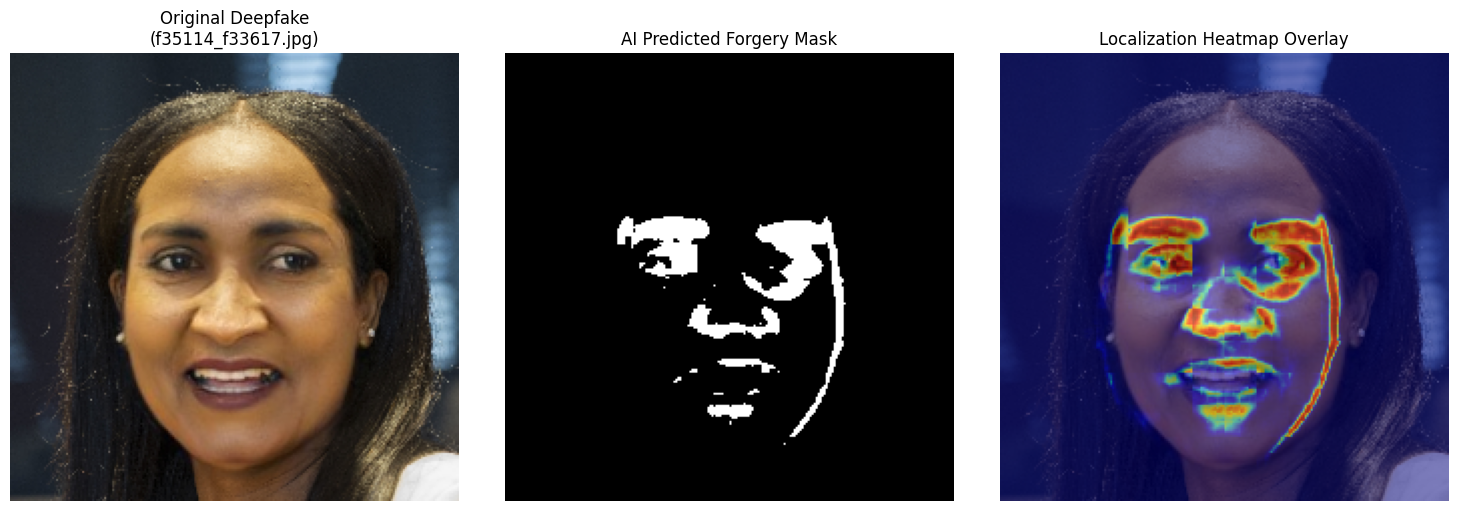

In [16]:
WEIGHTS_PATH = '/kaggle/input/datasets/rbbharatheesh/20th-epoch-pth-file/swin_unet_epoch_20.pth'
model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=device))
model.eval() 
print("Successfully loaded trained Swin-UNet weights!")

fake_name, real_name = random.choice(train_dataset.valid_pairs)
fake_path = os.path.join(KAGGLE_FAKE_DIR, fake_name)

raw_image = cv2.imread(fake_path)
raw_image = cv2.cvtColor(raw_image, cv2.COLOR_BGR2RGB)
raw_image_resized = cv2.resize(raw_image, (224, 224))

dummy_mask = np.zeros((224, 224), dtype=np.float32)
augmented = train_transform(image=raw_image_resized, mask=dummy_mask)
image_tensor = augmented['image'].unsqueeze(0).to(device)

with torch.no_grad():
    prediction = model(image_tensor)
    pred_mask = prediction.squeeze().cpu().numpy()
    
    # Threshold the prediction (confidence > 50% = fake pixel)
    pred_mask_binary = (pred_mask > 0.5).astype(np.uint8)

fig, arr = plt.subplots(1, 3, figsize=(15, 5))

arr[0].imshow(raw_image_resized)
arr[0].set_title(f'Original Deepfake\n({fake_name})', fontsize=12)
arr[0].axis('off')

arr[1].imshow(pred_mask_binary, cmap='gray')
arr[1].set_title('AI Predicted Forgery Mask', fontsize=12)
arr[1].axis('off')

# Create the heatmap overlay
arr[2].imshow(raw_image_resized)
arr[2].imshow(pred_mask, cmap='jet', alpha=0.5) # Alpha controls transparency
arr[2].set_title('Localization Heatmap Overlay', fontsize=12)
arr[2].axis('off')

plt.tight_layout()
plt.show()

In [17]:
def calculate_metrics(pred_mask, true_mask):
    pred = pred_mask.view(-1)
    target = true_mask.view(-1)
    
    tp = (pred * target).sum()
    fp = (pred * (1 - target)).sum()
    fn = ((1 - pred) * target).sum()
    tn = ((1 - pred) * (1 - target)).sum()
    
    epsilon = 1e-7
    
    accuracy = (tp + tn) / (tp + tn + fp + fn + epsilon)
    iou = tp / (tp + fp + fn + epsilon)
    f1_score = (2 * tp) / ((2 * tp) + fp + fn + epsilon)
    
    return accuracy.item(), iou.item(), f1_score.item()

model.eval() 
total_acc, total_iou, total_f1 = 0.0, 0.0, 0.0

print("Starting Quantitative Evaluation across the dataset...")

with torch.no_grad(): 
    loop = tqdm(train_loader, leave=True)
    for images, masks in loop:
        images = images.to(device)
        masks = masks.to(device)
        
        outputs = model(images)
        
        # Threshold predictions (Confidence > 50% = Fake)
        outputs_binary = (outputs > 0.5).float()
        
        acc, iou, f1 = calculate_metrics(outputs_binary, masks)
        
        total_acc += acc
        total_iou += iou
        total_f1 += f1
        
        loop.set_description(f"Evaluating")
        loop.set_postfix(IoU=f"{iou:.4f}", F1=f"{f1:.4f}")

num_batches = len(train_loader)
avg_acc = total_acc / num_batches
avg_iou = total_iou / num_batches
avg_f1 = total_f1 / num_batches

print("\n" + "="*45)
print(" FINAL SWIN-UNET EVALUATION METRICS ")
print("="*45)
print(f"Pixel-wise Accuracy           : {avg_acc * 100:.2f}%")
print(f"Intersection over Union (IoU) : {avg_iou:.4f}")
print(f"F1-Score (Dice Coefficient)   : {avg_f1:.4f}")
print("="*45)

Starting Quantitative Evaluation across the dataset...


Evaluating: 100%|██████████| 1954/1954 [17:27<00:00,  1.87it/s, F1=0.5943, IoU=0.4228]


 FINAL SWIN-UNET EVALUATION METRICS 
Pixel-wise Accuracy           : 94.41%
Intersection over Union (IoU) : 0.3425
F1-Score (Dice Coefficient)   : 0.4994


In [26]:
METADATA_PATH = '/kaggle/input/datasets/rbbharatheesh/metadata/metadata.csv'

meta_df = pd.read_csv(METADATA_PATH)
meta_df = meta_df.drop_duplicates(subset=['ID'])
meta_dict = meta_df.set_index('ID')[['Gender', 'Age', 'Race']].to_dict('index')

bias_results = {
    'Gender': {},
    'Age': {},
    'Race': {}
}

def init_tracker():
    return {'ious': []}

model.eval()
print("Starting Bias Evaluation across demographics...")

with torch.no_grad():
    test_subset = train_dataset.valid_pairs[:2000] 
    
    for fake_name, real_name in tqdm(test_subset):
        # Extract the base ID (ex: 'c00003' from 'c00003_c12345.jpg')
        base_id = fake_name.split('_')[0]
        
        if base_id not in meta_dict:
            continue
            
        demographics = meta_dict[base_id]
        gender = demographics['Gender']
        age = demographics['Age']
        race = demographics['Race']
        
        fake_path = os.path.join(KAGGLE_FAKE_DIR, fake_name)
        real_path = os.path.join(KAGGLE_REAL_DIR, real_name)
        
        fake_img = cv2.imread(fake_path)
        real_img = cv2.imread(real_path)
        
        if fake_img is None or real_img is None:
            continue
            
        fake_img = cv2.cvtColor(fake_img, cv2.COLOR_BGR2RGB)
        real_img = cv2.cvtColor(real_img, cv2.COLOR_BGR2RGB)
        
        diff = cv2.absdiff(fake_img, real_img)
        gray_diff = cv2.cvtColor(diff, cv2.COLOR_RGB2GRAY)
        _, mask = cv2.threshold(gray_diff, 30, 255, cv2.THRESH_BINARY)
        mask = mask.astype(np.float32) / 255.0 
        
        augmented = train_transform(image=fake_img, mask=mask)
        image_tensor = augmented['image'].unsqueeze(0).to(device)
        mask_tensor = augmented['mask'].unsqueeze(0).to(device)
        
        output = model(image_tensor)
        output_binary = (output > 0.5).float()
        
        _, iou, _ = calculate_metrics(output_binary, mask_tensor)
        
        if gender not in bias_results['Gender']: bias_results['Gender'][gender] = init_tracker()
        bias_results['Gender'][gender]['ious'].append(iou)
        
        if age not in bias_results['Age']: bias_results['Age'][age] = init_tracker()
        bias_results['Age'][age]['ious'].append(iou)
        
        if race not in bias_results['Race']: bias_results['Race'][race] = init_tracker()
        bias_results['Race'][race]['ious'].append(iou)

print("\n" + "="*55)
print(" AI FAIRNESS & BIAS REPORT (IoU Scores) ")
print("="*55)

for category in ['Gender', 'Age', 'Race']:
    print(f"\n--- Performance by {category} ---")
    
    sorted_groups = sorted(bias_results[category].keys())
    
    for group in sorted_groups:
        metrics = bias_results[category][group]
        avg_iou = np.mean(metrics['ious'])
        count = len(metrics['ious'])
        print(f"{group:<12} : IoU = {avg_iou:.4f}  (Tested on {count} images)")
        
print("="*55)

Starting Bias Evaluation across demographics...


100%|██████████| 2000/2000 [02:03<00:00, 16.15it/s]


 AI FAIRNESS & BIAS REPORT (IoU Scores) 

--- Performance by Gender ---
Female       : IoU = 0.2920  (Tested on 1117 images)
Male         : IoU = 0.2928  (Tested on 882 images)

--- Performance by Age ---
Adult        : IoU = 0.2981  (Tested on 1654 images)
Child        : IoU = 0.2402  (Tested on 183 images)
Elderly      : IoU = 0.2923  (Tested on 162 images)

--- Performance by Race ---
Asian        : IoU = 0.2915  (Tested on 183 images)
Black        : IoU = 0.2901  (Tested on 126 images)
Indian       : IoU = 0.3037  (Tested on 41 images)
Latino       : IoU = 0.2838  (Tested on 142 images)
White        : IoU = 0.2931  (Tested on 1507 images)
